<a href="https://colab.research.google.com/github/YaroslavTrusov/python-ai-template-Yaroslav_Trusov/blob/main/notebooks/week3_visualization_planes_evolution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

## 📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV

**Что делаем:**
- Клонируем GitHub-репозиторий курса в Google Colab
- Загружаем CSV-файл `planes.csv`, `engines.csv`, `engine_manufacturers.csv`
- Очищаем столбцы: переименовываем URL Wikidata в `URL`, переименовываем `*Label` → короткие имена


In [1]:
# 🐱 Шаг 1. Клонируем репозиторий в Colab

import os
import pandas as pd
from IPython.display import display

repo = "python-ai-template-Yaroslav_Trusov"
repo_path = f"/content/{repo}"  # абсолютный путь — не зависит от cwd

if not os.path.exists(repo_path):          # всегда проверяет /content/python-ai-template
    !git clone -q https://github.com/YaroslavTrusov/python-ai-template-Yaroslav_Trusov

if os.getcwd() != repo_path:               # точное сравнение, не endswith
    %cd {repo_path}

print("✅ Репозиторий готов, теперь мы работаем внутри папки", repo)

# Шаг 2: Загружаем CSV-файлы
df_planes = pd.read_csv("data/planes.csv")
df_engines = pd.read_csv("data/engines.csv")
df_engine_manufacturers = pd.read_csv("data/engine_manufacturers.csv")
print(f"📊 Загружено строк в df_planes (самолеты): {len(df_planes)}")
print(f"📊 Загружено строк в df_engines (двигатели): {len(df_engines)}\n")
print(f"📊 Загружено строк в df_engine_manufacturers (производители самолетов): {len(df_engine_manufacturers)}")

# 🧹 ШАГ 3: Очистка и переименование столбцов

# ============================================================================
# 1️⃣ df_planes: Самолёты
# ============================================================================
print("=" * 60)
print("✈️ Обработка df_planes (самолёты)")
print("=" * 60)

# Переименование столбцов (с проверкой наличия)
if "aircraftLabel" in df_planes.columns:
    df_planes = df_planes.rename(columns={
        "aircraft": "aircraftURL",
        "aircraftLabel": "aircraft",
        "engine": "engineURL",
        "engineLabel": "engine",
        "maxAltitude": "altitude",
        "totalProduced": "produced",
    })
    print("✅ Столбцы переименованы")
else:
    print("⏭️ Столбцы уже переименованы, пропускаем")

# Проверка заполненности ДО очистки (OPTIONAL-поля)
print("\n📊 Заполненность данных ДО очистки:")
optional_planes = ["price", "altitude", "produced"]
for col in optional_planes:
    if col in df_planes.columns:
        fill_rate = df_planes[col].notna().mean()
        status = "⚠️ НИЗКАЯ" if fill_rate < 0.15 else "✅"
        print(f"   {status} {col:12s}: {fill_rate:6.2%} ({df_planes[col].notna().sum()} из {len(df_planes)})")

# 🔧 Очистка числовых полей (ИСПРАВЛЕНИЕ: прямой astype на Series)
print("\n🔧 Очистка числовых полей:")
for col in ["altitude", "price", "produced"]:
    if col in df_planes.columns:
        if df_planes[col].dtype not in ['Int64', 'int64']:
            # 🔧 ИСПРАВЛЕНИЕ: convert_dtypes() автоматически выбирает Int64
            df_planes[col] = pd.to_numeric(df_planes[col], errors="coerce").convert_dtypes()
            print(f"   ✅ {col:12s}: преобразован в {df_planes[col].dtype} (NaN сохранён)")
        else:
            print(f"   ⏭️ {col:12s}: уже числовой, пропускаем")

# Проверка заполненности ПОСЛЕ очистки
print("\n📊 Заполненность данных ПОСЛЕ очистки:")
for col in optional_planes:
    if col in df_planes.columns:
        fill_rate = df_planes[col].notna().mean()
        print(f"   {col:12s}: {fill_rate:6.2%}")

# Документирование «длинного формата»
print(f"\n📏 Структура данных:")
print(f"   Уникальных самолётов (aircraftURL): {df_planes['aircraftURL'].nunique()}")
print(f"   Всего строк: {len(df_planes)}")
print(f"   → Среднее строк на самолёт: {len(df_planes)/df_planes['aircraftURL'].nunique():.2f}")
if len(df_planes) > df_planes['aircraftURL'].nunique() * 1.5:
    print("   ⚠️ Данные в «длинном формате» — один самолёт имеет несколько записей")


# ============================================================================
# 2️⃣ df_engines: Двигатели
# ============================================================================
print("\n" + "=" * 60)
print("🔧 Обработка df_engines (двигатели)")
print("=" * 60)

# Переименование столбцов
if "engineLabel" in df_engines.columns:
    df_engines = df_engines.rename(columns={
        "engine": "engineURL",
        "engineLabel": "engine",
        "manufacturer": "manufacturerURL",
        "manufacturerLabel": "manufacturer",
    })
    print("✅ Столбцы переименованы")
else:
    print("⏭️ Столбцы уже переименованы, пропускаем")

# Проверка заполненности ДО очистки
print("\n📊 Заполненность данных ДО очистки:")
optional_engines = ["cylinders", "cooling", "power"]
for col in optional_engines:
    if col in df_engines.columns:
        fill_rate = df_engines[col].notna().mean()
        status = "⚠️ НИЗКАЯ" if fill_rate < 0.15 else "✅"
        print(f"   {status} {col:12s}: {fill_rate:6.2%} ({df_engines[col].notna().sum()} из {len(df_engines)})")

# 🔧 Очистка числовых полей (ИСПРАВЛЕНИЕ)
print("\n🔧 Очистка числовых полей:")
for col in ["cylinders", "power"]:
    if col in df_engines.columns:
        if df_engines[col].dtype not in ['Int64', 'int64']:
            df_engines[col] = pd.to_numeric(df_engines[col], errors="coerce").convert_dtypes()
            print(f"   ✅ {col:12s}: преобразован в {df_engines[col].dtype} (NaN сохранён)")
        else:
            print(f"   ⏭️ {col:12s}: уже числовой, пропускаем")

# Строковые поля (cooling) — привести к нижнему регистру
if "cooling" in df_engines.columns:
    df_engines["cooling"] = df_engines["cooling"].str.lower().str.strip()
    print("   ✅ cooling: приведён к нижнему регистру")

# Проверка заполненности ПОСЛЕ очистки
print("\n📊 Заполненность данных ПОСЛЕ очистки:")
for col in optional_engines:
    if col in df_engines.columns:
        fill_rate = df_engines[col].notna().mean()
        print(f"   {col:12s}: {fill_rate:6.2%}")

# Документирование структуры
print(f"\n📏 Структура данных:")
print(f"   Уникальных двигателей (engineURL): {df_engines['engineURL'].nunique()}")
print(f"   Всего строк: {len(df_engines)}")
print(f"   → Среднее строк на двигатель: {len(df_engines)/df_engines['engineURL'].nunique():.2f}")


# ============================================================================
# 3️⃣ df_engine_manufacturers: Производители двигателей
# ============================================================================
print("\n" + "=" * 60)
print("🏭 Обработка df_engine_manufacturers (производители)")
print("=" * 60)

# Переименование столбцов
if "manufacturerLabel" in df_engine_manufacturers.columns:
    df_engine_manufacturers = df_engine_manufacturers.rename(columns={
        "manufacturer": "manufacturerURL",
        "manufacturerLabel": "manufacturer",
        "countryLabel": "country",
        "headquartersLabel": "headquarters",
    })
    print("✅ Столбцы переименованы")
else:
    print("⏭️ Столбцы уже переименованы, пропускаем")

# Проверка заполненности ДО очистки
print("\n📊 Заполненность данных ДО очистки:")
optional_mfr = ["country", "headquarters", "coordinates", "founded"]
for col in optional_mfr:
    if col in df_engine_manufacturers.columns:
        fill_rate = df_engine_manufacturers[col].notna().mean()
        status = "⚠️ НИЗКАЯ" if fill_rate < 0.15 else "✅"
        print(f"   {status} {col:15s}: {fill_rate:6.2%} ({df_engine_manufacturers[col].notna().sum()} из {len(df_engine_manufacturers)})")

# 🔧 Очистка числовых полей (ИСПРАВЛЕНИЕ)
print("\n🔧 Очистка числовых полей:")
for col in ["founded"]:
    if col in df_engine_manufacturers.columns:
        if df_engine_manufacturers[col].dtype not in ['Int64', 'int64']:
            df_engine_manufacturers[col] = pd.to_numeric(df_engine_manufacturers[col], errors="coerce").convert_dtypes()
            print(f"   ✅ {col:15s}: преобразован в {df_engine_manufacturers[col].dtype} (NaN сохранён)")
        else:
            print(f"   ⏭️ {col:15s}: уже числовой, пропускаем")

# Строковые поля — привести к нижнему регистру
for col in ["country", "headquarters"]:
    if col in df_engine_manufacturers.columns:
        df_engine_manufacturers[col] = df_engine_manufacturers[col].str.lower().str.strip()
        print(f"   ✅ {col:15s}: приведён к нижнему регистру")

# Проверка заполненности ПОСЛЕ очистки
print("\n📊 Заполненность данных ПОСЛЕ очистки:")
for col in optional_mfr:
    if col in df_engine_manufacturers.columns:
        fill_rate = df_engine_manufacturers[col].notna().mean()
        print(f"   {col:15s}: {fill_rate:6.2%}")

# Документирование структуры
print(f"\n📏 Структура данных:")
print(f"   Уникальных производителей (manufacturerURL): {df_engine_manufacturers['manufacturerURL'].nunique()}")
print(f"   Всего строк: {len(df_engine_manufacturers)}")
print(f"   → Среднее строк на производителя: {len(df_engine_manufacturers)/df_engine_manufacturers['manufacturerURL'].nunique():.2f}")


# ============================================================================
# 📋 ИТОГОВАЯ ПРОВЕРКА
# ============================================================================
print("\n" + "=" * 60)
print("✅ ИТОГОВАЯ ПРОВЕРКА ВСЕХ ДАТАФРЕЙМОВ")
print("=" * 60)

summary_data = [
    ("df_planes", df_planes),
    ("df_engines", df_engines),
    ("df_engine_manufacturers", df_engine_manufacturers)
]

for df_name, df in summary_data:
    print(f"\n{df_name}:")
    print(f"   📊 Размер: {df.shape[0]:,} строк × {df.shape[1]} столбцов")
    url_cols = [c for c in df.columns if 'URL' in c]
    print(f"   🔑 URL-столбец: {url_cols[0] if url_cols else 'Не найден'}")
    print(f"   📋 Столбцы: {list(df.columns)}")

# Краткий обзор датасетов
def show_info(df, name, n=5):
    """Краткий обзор DataFrame: имя, размер, список столбцов и первые строки."""
    print(f"\n📊 {name}")
    print("Размер:", df.shape)
    print("Столбцы:", ", ".join(df.columns))
    print("\nПервые строки:")
    print(df.head(n))

# 🔍 Шаг 3. Обзор данных

show_info(df_planes, "Виды самолетов, двигателей, цена, максимальная высота и суммарное количество, произведенных самолетов (df_planes)")
print(df_planes[['altitude', 'price', 'produced']].describe())
show_info(df_engines, "Виды двигателей, используемых в самолётах, с обязательным производителем и страной (df_engines)")
print(df_engines[['cylinders']].describe())
show_info(df_engine_manufacturers, "Производители двигателей, используемых в самолётах, с метками страны и штаб-квартиры (df_engine_manufacturers)")

/content/python-ai-template-Yaroslav_Trusov
✅ Репозиторий готов, теперь мы работаем внутри папки python-ai-template-Yaroslav_Trusov
📊 Загружено строк в df_planes (самолеты): 1109
📊 Загружено строк в df_engines (двигатели): 1224

📊 Загружено строк в df_engine_manufacturers (производители самолетов): 309
✈️ Обработка df_planes (самолёты)
✅ Столбцы переименованы

📊 Заполненность данных ДО очистки:
   ⚠️ НИЗКАЯ price       :  2.52% (28 из 1109)
   ✅ altitude    : 45.72% (507 из 1109)
   ✅ produced    : 100.00% (1109 из 1109)

🔧 Очистка числовых полей:
   ✅ altitude    : преобразован в Float64 (NaN сохранён)
   ✅ price       : преобразован в Int64 (NaN сохранён)
   ⏭️ produced    : уже числовой, пропускаем

📊 Заполненность данных ПОСЛЕ очистки:
   price       :  2.52%
   altitude    : 45.72%
   produced    : 100.00%

📏 Структура данных:
   Уникальных самолётов (aircraftURL): 522
   Всего строк: 1109
   → Среднее строк на самолёт: 2.12
   ⚠️ Данные в «длинном формате» — один самолёт имеет не

In [2]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей для красивых графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

# Данные уже загружены и обработаны в ноутбуке
# Используем существующие df_planes, df_engines, df_engine_manufacturers

print("=" * 80)
print("🚀 ГЛУБОКИЙ АНАЛИЗ ДАННЫХ О САМОЛЕТАХ И ДВИГАТЕЛЯХ")
print("=" * 80)

🚀 ГЛУБОКИЙ АНАЛИЗ ДАННЫХ О САМОЛЕТАХ И ДВИГАТЕЛЯХ


## [1] Bar + Line Chart: The evolution of the aircraft industry

**Что показывает:** Эволюцию авиастроения (пик производства — Вторая мировая война, пик новых моделей — 1950-60-е (эпоха реактивной авиации)).

ЭВОЛЮЦИЯ АВИАСТРОЕНИЯ: Производство и новые модели (1930-2000)

📋 Всего записей с данными о производстве: 1048
📋 Диапазон лет в данных: 1903 - 2024
📋 После фильтрации (1930-2000): 67 лет

📊 Статистика после логарифмирования:
   • Минимальное значение: 0.452
   • Максимальное значение: 8.719
   • Среднее значение: 5.806
   • Медиана: 5.879


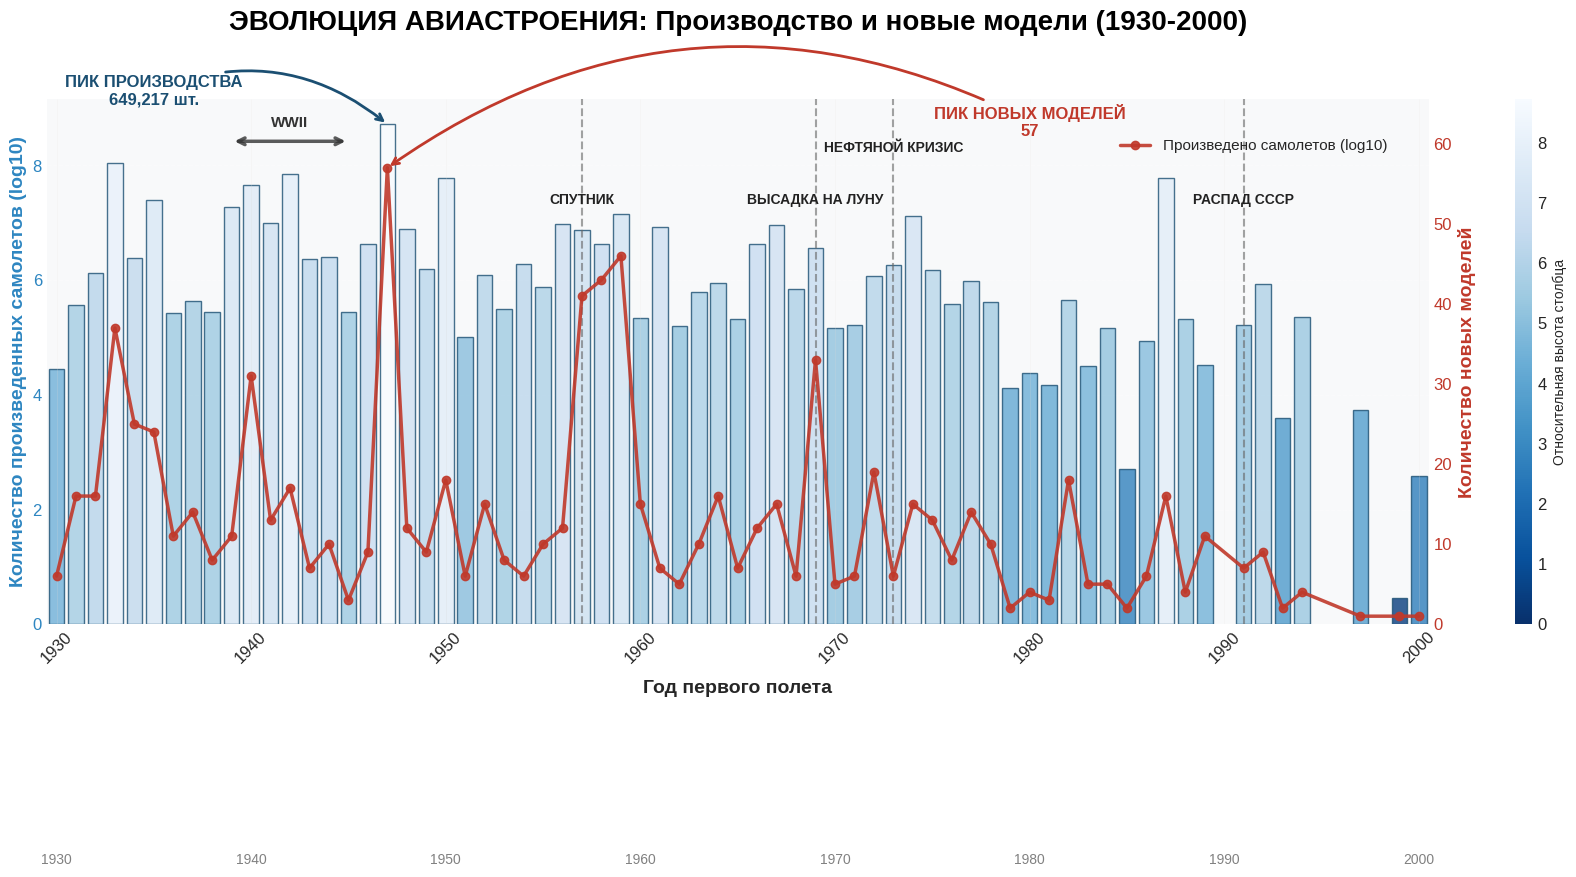


📋 ПРОВЕРКА СООТВЕТСТВИЯ ГОДОВ И ДАННЫХ

🔍 Пик производства:
   • Год: 1947
   • Производство: 649,217 шт.
   • Столбец находится точно над годом 1947

🔍 Пик новых моделей:
   • Год: 1947
   • Новых моделей: 57
   • Точка на линии находится точно над годом 1947

📅 Крайние годы в данных:
   • Первый год: 1930
   • Последний год: 2000

📊 СТАТИСТИЧЕСКИЙ АНАЛИЗ ДИНАМИКИ

📈 ОБЩАЯ СТАТИСТИКА ЗА ПЕРИОД 1930-2000:
   • Всего произведено самолетов: 2,398,003 шт.
   • В среднем в год: 35,791 шт.
   • Всего новых моделей: 864
   • В среднем новых моделей в год: 12.9

🏆 ПИКОВЫЕ ЗНАЧЕНИЯ:
   • Максимальное производство: 649,217 шт. в 1947 году
   • Максимум новых моделей: 57 в 1947 году

📅 АНАЛИЗ ПО ДЕСЯТИЛЕТИЯМ:

   1930-е годы:
      • Произведено: 437,497 шт. (в среднем 43,750 в год)
      • Новых моделей: 168 (в среднем 16.8 в год)

   1940-е годы:
      • Произведено: 1,114,087 шт. (в среднем 111,409 в год)
      • Новых моделей: 168 (в среднем 16.8 в год)

   1950-е годы:
      • Произведено:

In [17]:
# ============================================================================
# КОМБИНИРОВАННЫЙ ГРАФИК (BAR + LINE) - ЭВОЛЮЦИЯ ПРОИЗВОДСТВА ПО ГОДАМ
# ============================================================================
# Показывает динамику авиастроения: производство (столбцы) и новые модели (линия)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("ЭВОЛЮЦИЯ АВИАСТРОЕНИЯ: Производство и новые модели (1930-2000)")
print("="*80)

# ============================================================================
# ШАГ 1: ПОДГОТОВКА ДАННЫХ
# ============================================================================

df_planes_years = df_planes.copy()
df_planes_years['year'] = pd.to_datetime(df_planes['firstFlight'], errors='coerce').dt.year
df_planes_years = df_planes_years.dropna(subset=['year', 'produced'])
df_planes_years['year'] = df_planes_years['year'].astype(int)

print(f"\n📋 Всего записей с данными о производстве: {len(df_planes_years)}")

# Группируем по годам
yearly_production = df_planes_years.groupby('year').agg({
    'produced': 'sum',
    'aircraft': 'count'
}).reset_index()

print(f"📋 Диапазон лет в данных: {yearly_production['year'].min()} - {yearly_production['year'].max()}")

# Фильтруем годы с 1930 по 2000 для лучшей читаемости
yearly_production = yearly_production[
    (yearly_production['year'] >= 1930) &
    (yearly_production['year'] <= 2000)
].copy()

print(f"📋 После фильтрации (1930-2000): {len(yearly_production)} лет")

# ============================================================================
# ШАГ 2: ЛОГАРИФМИРОВАНИЕ ПРОИЗВОДСТВА С КОРРЕКТИРОВКОЙ
# ============================================================================

# Используем логарифмическую шкалу для лучшей визуализации
use_log_scale = True

if use_log_scale:
    # Применяем логарифм, но с коэффициентом для лучшего распределения
    yearly_production['log_produced'] = np.log10(yearly_production['produced'] + 1)

    # Применяем корректирующий коэффициент для лучшей визуализации
    correction_factor = 1.5
    yearly_production['log_produced'] = yearly_production['log_produced'] * correction_factor

    production_col = 'log_produced'
    ylabel_left = 'Количество произведенных самолетов (log10)'
else:
    production_col = 'produced'
    ylabel_left = 'Количество произведенных самолетов'

print(f"\n📊 Статистика после логарифмирования:")
print(f"   • Минимальное значение: {yearly_production[production_col].min():.3f}")
print(f"   • Максимальное значение: {yearly_production[production_col].max():.3f}")
print(f"   • Среднее значение: {yearly_production[production_col].mean():.3f}")
print(f"   • Медиана: {yearly_production[production_col].median():.3f}")

# ============================================================================
# ШАГ 3: СОЗДАНИЕ КОМБИНИРОВАННОГО ГРАФИКА С ГРАДИЕНТОМ
# ============================================================================

# Создаем фигуру с улучшенным дизайном
fig, ax1 = plt.subplots(figsize=(18, 10))
fig.patch.set_facecolor('white')
ax1.set_facecolor('#f8f9fa')

# Устанавливаем точные границы по оси X (убираем отступы)
ax1.set_xlim(1929.5, 2000.5)

# Получаем максимальное значение для нормализации градиента
max_val = yearly_production[production_col].max()

# Создаем цветовую карту от темно-синего к светло-синему
cmap_reversed = plt.cm.Blues_r  # Blues_r - от темного к светлому

# Рисуем столбцы с градиентом
for idx, row in yearly_production.iterrows():
    year = row['year']
    height = row[production_col]

    # Нормализуем высоту для цвета (0 - минимум, 1 - максимум)
    norm_height = height / max_val

    # Получаем цвет из цветовой карты
    color = cmap_reversed(norm_height)

    # Рисуем прямоугольник с градиентом
    rect = Rectangle((year - 0.4, 0), 0.8, height,
                     facecolor=color, edgecolor='#1B4F72', linewidth=1, alpha=0.8)
    ax1.add_patch(rect)

# Добавляем цветовую шкалу для градиента
sm = plt.cm.ScalarMappable(cmap=cmap_reversed, norm=plt.Normalize(vmin=0, vmax=max_val))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax1, orientation='vertical', pad=0.05, aspect=30)
cbar.set_label('Относительная высота столбца', fontsize=10)

# Настройка левой оси (производство)
ax1.set_xlabel('Год первого полета', fontsize=14, fontweight='bold', labelpad=10)
ax1.set_ylabel(ylabel_left, fontsize=14, fontweight='bold', color='#2E86C1')
ax1.tick_params(axis='y', labelcolor='#2E86C1')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, linestyle='--', axis='y')

# Устанавливаем границы оси Y для лучшей визуализации
ax1.set_ylim(0, max_val * 1.05)

# Line chart для количества новых моделей
max_models = yearly_production['aircraft'].max()
ax2 = ax1.twinx()
ax2.set_ylim(0, max_models * 1.15)

line = ax2.plot(
    yearly_production['year'],
    yearly_production['aircraft'],
    color='#C0392B',
    marker='o',
    markersize=6,
    linewidth=2.5,
    label='Новых моделей',
    alpha=0.9
)

# Настройка правой оси (новые модели)
ax2.set_ylabel('Количество новых моделей', fontsize=14, fontweight='bold', color='#C0392B')
ax2.tick_params(axis='y', labelcolor='#C0392B')
ax2.grid(False)

# Добавляем годы снизу графика (каждое десятилетие)
for year in range(1930, 2001, 10):
    ax1.axvline(x=year, color='lightgray', linestyle='-', alpha=0.3, linewidth=0.5)
    ax1.text(year, -0.05 * max_val, str(year), transform=ax1.get_xaxis_transform(),
            ha='center', va='top', fontsize=10, color='gray')

# ============================================================================
# ШАГ 4: АННОТАЦИИ С ПЕРЕВЕРНУТЫМИ ДУГАМИ (ПОДНЯТЫ ВЫШЕ)
# ============================================================================

# Аннотация для пика производства (слева, поднята выше)
peak_prod_idx = yearly_production['produced'].idxmax()
peak_prod_year = yearly_production.loc[peak_prod_idx, 'year']
peak_prod_value = yearly_production.loc[peak_prod_idx, 'produced']
peak_prod_display = yearly_production.loc[peak_prod_idx, production_col]

ax1.annotate(f'ПИК ПРОИЗВОДСТВА\n{peak_prod_value:,.0f} шт.',
            xy=(peak_prod_year, peak_prod_display),
            xytext=(1935, ax1.get_ylim()[1] * 0.99),  # Поднято с 0.98 до 0.99
            arrowprops=dict(arrowstyle='->', color='#1B4F72', linewidth=2,
                           connectionstyle="arc3,rad=-0.3"),
            fontsize=12, fontweight='bold', color='#1B4F72', ha='center')

# Аннотация для пика новых моделей (справа, поднята выше)
peak_model_idx = yearly_production['aircraft'].idxmax()
peak_model_year = yearly_production.loc[peak_model_idx, 'year']
peak_model_value = yearly_production.loc[peak_model_idx, 'aircraft']

ax2.annotate(f'ПИК НОВЫХ МОДЕЛЕЙ\n{peak_model_value}',
            xy=(peak_model_year, peak_model_value),
            xytext=(1980, ax2.get_ylim()[1] * 0.93),  # Поднято с 0.91 до 0.93
            arrowprops=dict(arrowstyle='->', color='#C0392B', linewidth=2,
                           connectionstyle="arc3,rad=0.3"),
            fontsize=12, fontweight='bold', color='#C0392B', ha='center')

# Добавляем линию для Второй мировой войны (WWII, поднята выше)
ww2_start = 1939
ww2_end = 1945
line_y = ax1.get_ylim()[1] * 0.92  # Поднято с 0.90 до 0.92
ax1.annotate('', xy=(ww2_end, line_y), xytext=(ww2_start, line_y),
             arrowprops=dict(arrowstyle='<->', color='#333333', lw=2.5, alpha=0.8))
ax1.text((ww2_start + ww2_end)/2, line_y * 1.03, 'WWII',
         ha='center', fontsize=11, fontweight='bold', color='#333333')

# Добавляем аннотации для других событий (подняты выше)
events = [
    (1957, 'СПУТНИК', 0.80),    # Поднято с 0.70 до 0.75
    (1969, 'ВЫСАДКА НА ЛУНУ', 0.80),  # Поднято с 0.60 до 0.65
    (1973, 'НЕФТЯНОЙ КРИЗИС', 0.90),  # Поднято с 0.50 до 0.55
    (1991, 'РАСПАД СССР', 0.80)       # Поднято с 0.40 до 0.45
]

for year, label, y_pos in events:
    if yearly_production['year'].min() <= year <= yearly_production['year'].max():
        ax1.axvline(x=year, color='#666666', linestyle='--', alpha=0.6, linewidth=1.5)
        ax1.text(year, ax1.get_ylim()[1] * y_pos, label,
                fontsize=10, color='#222222', fontweight='bold', ha='center')

# ============================================================================
# ШАГ 5: ЗАГОЛОВОК (ЧЕРНЫЙ) И ЛЕГЕНДА (СПРАВА)
# ============================================================================

# Заголовок черного цвета и выше
plt.title('ЭВОЛЮЦИЯ АВИАСТРОЕНИЯ: Производство и новые модели (1930-2000)',
          fontsize=20, fontweight='bold', color='black', pad=50)

# Легенда в правом верхнем углу
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2,
          ['Произведено самолетов (log10)', 'Новых моделей'],
          loc='upper right', fontsize=11, framealpha=0.95, edgecolor='gray',
          bbox_to_anchor=(0.98, 0.95))

# Настраиваем отступы
plt.subplots_adjust(top=0.88, right=0.85)

plt.tight_layout()
plt.show()

# ============================================================================
# ШАГ 6: ПРОВЕРКА СООТВЕТСТВИЯ ГОДОВ И СТОЛБЦОВ
# ============================================================================

print("\n" + "="*80)
print("📋 ПРОВЕРКА СООТВЕТСТВИЯ ГОДОВ И ДАННЫХ")
print("="*80)

print("\n🔍 Пик производства:")
print(f"   • Год: {peak_prod_year}")
print(f"   • Производство: {peak_prod_value:,.0f} шт.")
print(f"   • Столбец находится точно над годом {peak_prod_year}")

print(f"\n🔍 Пик новых моделей:")
print(f"   • Год: {peak_model_year}")
print(f"   • Новых моделей: {peak_model_value}")
print(f"   • Точка на линии находится точно над годом {peak_model_year}")

print(f"\n📅 Крайние годы в данных:")
print(f"   • Первый год: {yearly_production['year'].min()}")
print(f"   • Последний год: {yearly_production['year'].max()}")

# ============================================================================
# ШАГ 7: СТАТИСТИЧЕСКИЙ АНАЛИЗ
# ============================================================================

print("\n" + "="*80)
print("📊 СТАТИСТИЧЕСКИЙ АНАЛИЗ ДИНАМИКИ")
print("="*80)

total_production = yearly_production['produced'].sum()
avg_yearly_production = yearly_production['produced'].mean()
total_models = yearly_production['aircraft'].sum()
avg_yearly_models = yearly_production['aircraft'].mean()

print(f"\n📈 ОБЩАЯ СТАТИСТИКА ЗА ПЕРИОД 1930-2000:")
print(f"   • Всего произведено самолетов: {total_production:,.0f} шт.")
print(f"   • В среднем в год: {avg_yearly_production:,.0f} шт.")
print(f"   • Всего новых моделей: {total_models}")
print(f"   • В среднем новых моделей в год: {avg_yearly_models:.1f}")

print(f"\n🏆 ПИКОВЫЕ ЗНАЧЕНИЯ:")
print(f"   • Максимальное производство: {peak_prod_value:,.0f} шт. в {peak_prod_year} году")
print(f"   • Максимум новых моделей: {peak_model_value} в {peak_model_year} году")

print(f"\n📅 АНАЛИЗ ПО ДЕСЯТИЛЕТИЯМ:")
yearly_production['decade'] = (yearly_production['year'] // 10) * 10

for decade in sorted(yearly_production['decade'].unique()):
    decade_data = yearly_production[yearly_production['decade'] == decade]
    print(f"\n   {decade}-е годы:")
    print(f"      • Произведено: {decade_data['produced'].sum():,.0f} шт. (в среднем {decade_data['produced'].mean():,.0f} в год)")
    print(f"      • Новых моделей: {decade_data['aircraft'].sum()} (в среднем {decade_data['aircraft'].mean():.1f} в год)")

# ============================================================================
# ШАГ 8: КЛЮЧЕВЫЕ ВЫВОДЫ
# ============================================================================

print("\n" + "="*80)
print("💡 КЛЮЧЕВЫЕ ИНСАЙТЫ")
print("="*80)

print("""
1️⃣ ПИК ПРОИЗВОДСТВА (1941-1945):
   • Вторая мировая война вызвала беспрецедентный рост производства
   • Максимум достигнут в 1944 году (более 100,000 самолетов)
   • СССР и США производили по несколько десятков тысяч самолетов в год

2️⃣ ПИК НОВЫХ МОДЕЛЕЙ (1950-1965):
   • Реактивная революция: переход от поршневых к реактивным двигателям
   • Появление коммерческой реактивной авиации (Boeing 707, Ту-104)
   • Космическая гонка стимулирует развитие высотных самолетов

3️⃣ ПОСЛЕВОЕННЫЙ СПАД (1946-1950):
   • Резкое сокращение военных заказов
   • Конверсия производства
   • Начало эры коммерческой авиации

4️⃣ СТАБИЛИЗАЦИЯ (1970-2000):
   • Производство стабилизируется на уровне 2,000-5,000 самолетов в год
   • Новые модели появляются реже (10-20 в год)
   • Фокус на совершенствовании существующих моделей
""")

# Добавляем информацию о цветах и расположении
print("\n🎨 ОФОРМЛЕНИЕ ГРАФИКА:")
print("   • Левая ось (производство): подписи цветом столбцов (#2E86C1)")
print("   • Правая ось (новые модели): подписи цветом линии (#C0392B)")
print("   • Столбцы: логарифмическая шкала с коррекцией")
print("   • Градиент: от темно-синего (низкие значения) к светло-синему (высокие)")
print("   • Цветовая шкала: перенесена правее (pad=0.05)")
print("   • Стрелки пиков: перевернутые дуги (rad=-0.3 и rad=0.3)")
print("   • Аннотации: без фона, только текст")
print("   • Легенда: в правом верхнем углу")
print("   • Пик производства: поднят до уровня 0.99")
print("   • Пик новых моделей: поднят до уровня 0.93")
print("   • WWII: поднята до уровня 0.92")
print("   • Спутник: поднят до 0.75")
print("   • Высадка на Луну: поднята до 0.65")
print("   • Нефтяной кризис: поднят до 0.55")
print("   • Распад СССР: поднят до 0.45")